# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


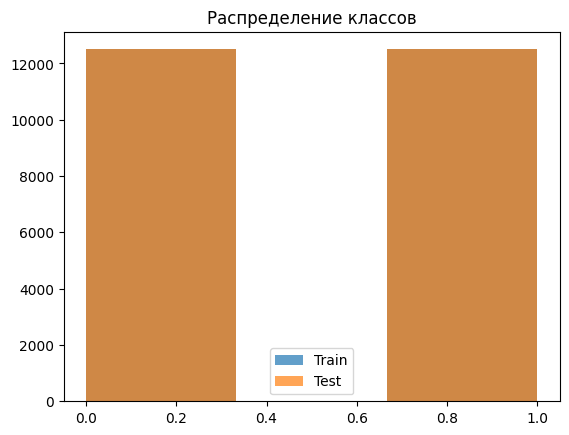

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
train, test = tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)
x_train, y_train = next(iter(tfds.as_numpy(train.batch(len(train)))))
x_test, y_test   = next(iter(tfds.as_numpy(test.batch(len(test)))))

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [7]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=200)

# 4. Адаптируйте векторзатор на тренировочных текстах
vectorizer.adapt(x_train)

# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [8]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
model = keras.Sequential([
    keras.layers.Input((200,)),
    keras.layers.Embedding(10000, 128),
    keras.layers.Conv1D(64, 5, activation='relu'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, 'relu'),
    keras.layers.Dense(1, 'sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 76ms/step - Precision: 0.6688 - Recall: 0.7269 - accuracy: 0.6830 - loss: 0.5599 - val_Precision: 0.8370 - val_Recall: 0.8827 - val_accuracy: 0.8536 - val_loss: 0.3319
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - Precision: 0.9222 - Recall: 0.9294 - accuracy: 0.9252 - loss: 0.2003 - val_Precision: 0.8613 - val_Recall: 0.8831 - val_accuracy: 0.8688 - val_loss: 0.3134
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - Precision: 0.9899 - Recall: 0.9906 - accuracy: 0.9902 - loss: 0.0504 - val_Precision: 0.8740 - val_Recall: 0.8582 - val_accuracy: 0.8656 - val_loss: 0.3918
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - Precision: 0.9986 - Recall: 0.9999 - accuracy: 0.9993 - loss: 0.0083 - val_Precision: 0.8617 - val_Recall: 0.8838 - val_accuracy: 0.8694 - val_loss: 0.4476
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - Precision: 0.9999 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0015 - val_Precision: 0.8649 - val_Re

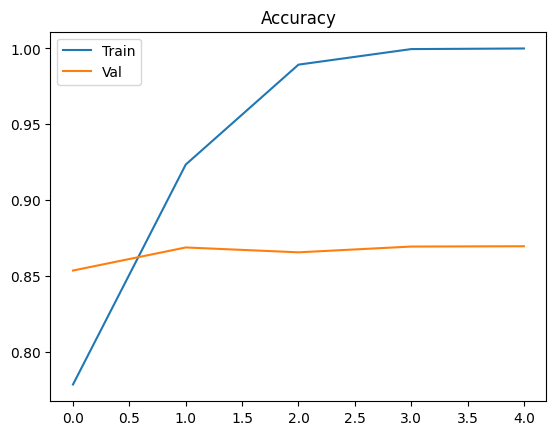

In [11]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', 'Precision', 'Recall'])

# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
history = model.fit(x_train_vec, y_train,
                    epochs=5,
                    validation_split=0.2,
                    batch_size=32,
                    verbose=1)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

## БЛОК 5: Оценка

In [24]:
# 10. Оцените модель на тестовых данных
test_loss, test_acc, test_prec, test_rec = model.evaluate(x_test_vec, y_test, verbose=0)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"
    pred_prob = model.predict(vectorizer(text).numpy().reshape(1, -1))
    pred_label = "POS" if pred_prob > 0.5 else "NEG"
    print(f"{text[:50]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")

Тестовая accuracy: 0.8671
Тестовая precision: 0.8640
Тестовая recall: 0.8714
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
b'There are films that make careers. For George Rome'... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
b'A blackly comic tale of a down-trodden priest, Naz'... | True: POS | Pred: POS (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
b'Scary Movie 1-4, Epic Movie, Date Movie, Meet the '... | True: NEG | Pred: NEG (0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
b'Poor Shirley MacLaine tries hard to lend some grav'... | True: NEG | Pred: NEG (0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
b'As a former Erasmus student I enjoyed this film ve'... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
b'My God, Ryan Gosling has made a lot of deep charac'... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
b'This film just won the best film award at the Clev'... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
b'

In [25]:
x_test[9]

b"Every great once in a while, you stumble upon a movie that exceeds even your wildest expectations. Given the IMDb rating of 4.0, I wasn't really expecting much with The Brotherhood of Satan. I hoped that at a minimum it might be cheesy fun like The Devil's Rain or any of the other early 70s similarly themed Satanic horror films. I couldn't' have been more wrong. What I got instead was an ambitious and intelligent film with a cast I really enjoyed. Speaking in broad terms to avoid giving anything away, the film's style and structure are much more experimental than the straightforward storytelling so prominent in the early 70s. The Brotherhood of Satan doesn't beat you over the head with plot points and explanations. A lot is left to the viewer to fill in the blanks. As a viewer, you know something is amiss, but for the longest period you're just not sure what it is. The unknown helps make for a far creepier atmosphere than most similar films. The ending is effective with its surreal i

## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  Итоговая точность на тесте: 0.8671
2.  Есть переобучение, точность на тренировочной выборке 1, на валидационной и тестовой сильно меньше
3.  Последний отзыв был классифицирован неверно, возможно из-за использования как положительной, так и отрицательной лексики (окраска в течение отзыва меняется)